## Basic plotting of daily precipitation using `uxarray` and `matplotlib` (Use environment `NPL 2025b`)

This notebook shows how to easily analyze and plot data (daily precip shown here) from any MPAS mesh. Make sure you use the environment `NPL 2025b`

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np
import xarray as xr
import uxarray as ux
import cartopy.feature as cfeature
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import glob

I didn't love the matplotlib colorbar options for temperature so I grabbed the following colormap from this github

https://github.com/blaylockbk/pyBKB_v2/blob/master/demos/National_Weather_Service_Standard_Color_Curves.ipynb

You can also always use whatever you want, such as `cmap="YlGnBu"`

In [2]:
a = [0, 2, 6, 10, 15, 20, 30, 40, 50, 60, 75, 100, 120, 140, 160, 200]
# Normalize the bin between 0 and 1 (uneven bins are important here)
norm = [(float(i)-min(a))/(max(a)-min(a)) for i in a]

# Color tuple for every bin
C = np.array([[255,255,255],[199,233,192],[161,217,155],[116,196,118],[49,163,83],
              [0,109,44],[255,250,138],[255,204,79],[254,141,60],[252,78,42],[214,26,28],
              [173,0,38],[112,0,38],[59,0,48],[76,0,115],[255,219,255]])

# Create a tuple for every color indicating the normalized position on the colormap and the assigned color.
COLORS = []
for i, n in enumerate(norm):
    COLORS.append((n, np.array(C[i])/255.))

# Create the colormap
cmap = colors.LinearSegmentedColormap.from_list("precipitation",COLORS)

Set path for data and load in using `ux.open_mfdataset` from `uxarray`. Also set what date/time we want to look at.

In [3]:
base_path = "../240-48km_variable/"
files = f"{base_path}diag*00.nc"
grid_path = f"{base_path}SouthAmerica.grid.nc"
uxds = ux.open_mfdataset(grid_path,files,combine="nested",concat_dim="Time")
plot_time = "2014-09-13 00"

Calculate 3hourly, daily and read in accumulated precipitation.

In [4]:
prec = uxds["rainc"] + uxds["rainnc"]
prec_3hr = prec.diff(dim="Time") # 3hourly precip
prec_daily = prec.resample(Time="1D",closed="right",label="left").max().diff(dim="Time") # Daily precip
prec_accum = prec.isel(Time=-1).squeeze() # Precip for length of entire model run. Just grabbed last timeslice

Let's just take a look at daily precip in a very simple way. This plot is also interactive. You can hover over it to see values and zoom in/out.

In [5]:
prec_daily.sel(Time=plot_time).plot()

:Image   [x,y]   (x_y var)

Here we make a much nicer plot for daily precip. If you want to plot 3hrly or accumulated, make sure you account for that by changing `clim`.

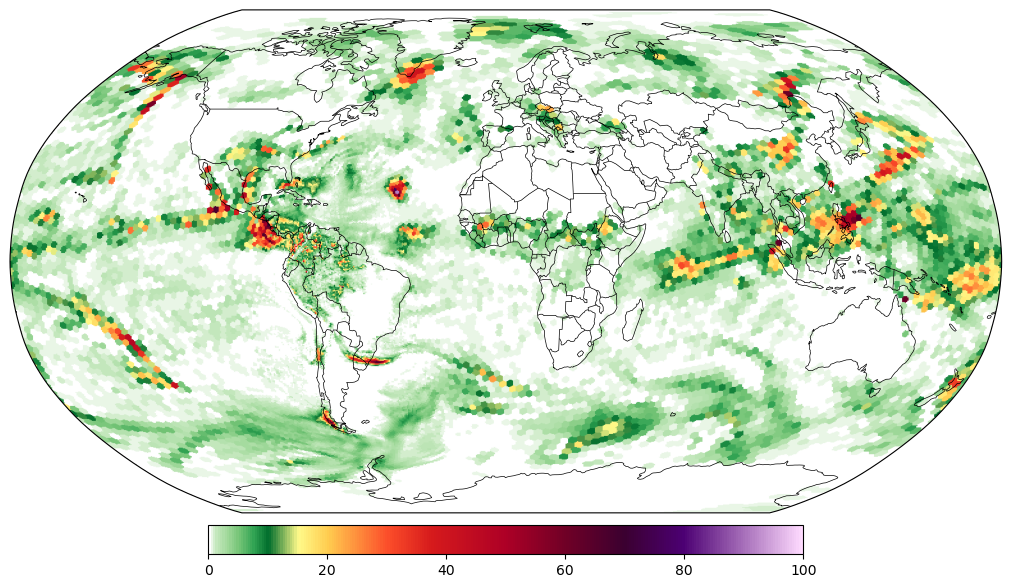

In [6]:
projection = ccrs.Robinson()
fig, ax = plt.subplots(figsize=(10,10), subplot_kw={"projection": projection},facecolor="w",layout="constrained")
ax.set_global()

raster = prec_daily.sel(Time=plot_time).to_raster(ax=ax)
im = ax.imshow(raster,origin="lower",extent=ax.get_xlim() + ax.get_ylim(),cmap=cmap,clim=(0,100),zorder=1)
ax.add_feature(cfeature.COASTLINE.with_scale("110m"), linewidth=0.5, edgecolor="black")
ax.add_feature(cfeature.BORDERS.with_scale("110m"), linewidth=0.5, edgecolor="black")

cbar = fig.colorbar(im,ax=ax,orientation="horizontal",pad=0.01,shrink=0.6)

#plt.savefig("precip_global.jpg", bbox_inches="tight", dpi=300)
plt.show()

Regional precip plot!

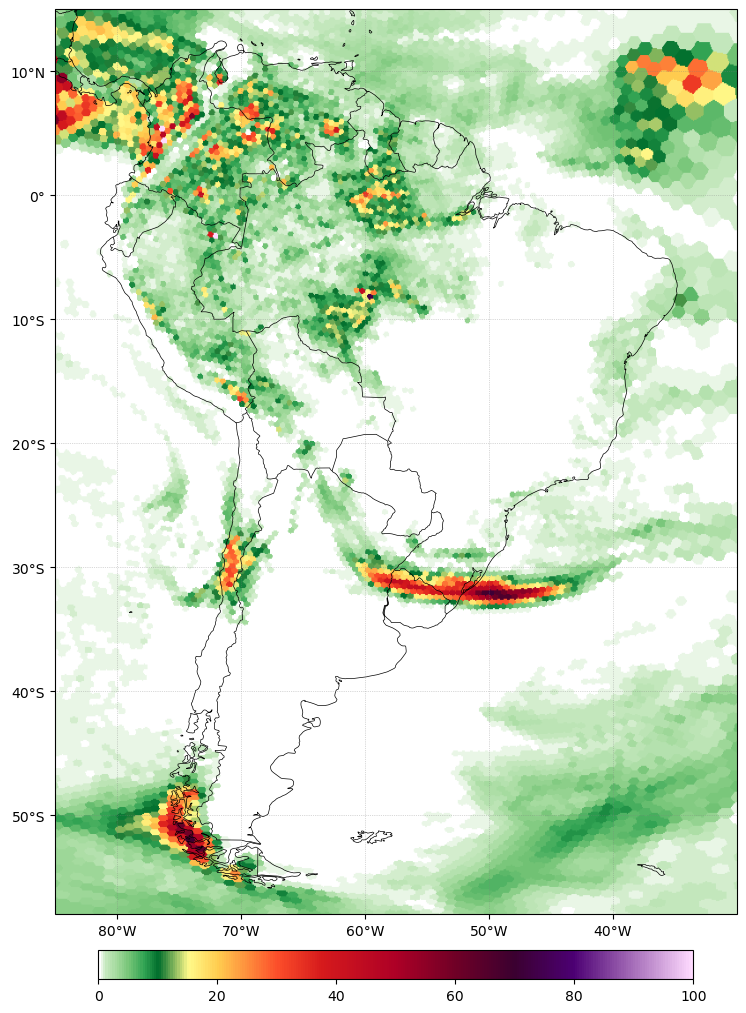

In [7]:
minLon, maxLon = -85, -30
minLat, maxLat = -58, 15
projection = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(10,10), subplot_kw={"projection": projection},facecolor="w",layout="constrained")
ax.set_extent([minLon,maxLon,minLat,maxLat],crs=ccrs.PlateCarree())

raster = prec_daily.sel(Time=plot_time).to_raster(ax=ax)
im = ax.imshow(raster,origin="lower",extent=ax.get_xlim() + ax.get_ylim(),cmap=cmap,clim=(0,100),zorder=1)
ax.add_feature(cfeature.COASTLINE.with_scale("50m"),linewidth=0.5,edgecolor="black")
ax.add_feature(cfeature.BORDERS.with_scale("50m"),linewidth=0.5,edgecolor="black")

# Add lats and lons
step = 10  # Change to 5 if you want ticks every 5 degrees
start_lat = np.ceil(minLat / step) * step
start_lon = np.ceil(minLon / step) * step
ax.set_yticks(np.arange(start_lat,maxLat,step),crs=projection)
ax.yaxis.set_major_formatter(LatitudeFormatter()); ax.tick_params(axis="y",labelsize=10)
ax.set_xticks(np.arange(start_lon,maxLon,step),crs=projection)
ax.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=True)); ax.tick_params(axis="x",labelsize=10)
ax.grid(True, linestyle=":", linewidth=0.5, color="gray", alpha=0.6)

cbar = fig.colorbar(im,ax=ax,orientation="horizontal",pad=0.01,shrink=0.6)

#plt.savefig("precip_samerica.jpg", bbox_inches="tight", dpi=300)
plt.show()